In [1]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.patches import Patch

# ── 한글 폰트 설정 (Colab: 나눔고딕) ──
!apt-get -qq install fonts-nanum > /dev/null
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 데이터 로드 (파일명 확인: .csv가 중복되지 않도록) ──
final = pd.read_csv('/content/아세트아미노펜_51개브랜드_전체행_최종.csv', low_memory=False)

# ── '전체_활성성분'에서 "단일 아세트아미노펜"을 하나라도 포함하면 그룹에 포함 ──
def contains_single(text):
    if pd.isna(text):
        return False
    segs = [s.strip() for s in text.split(';') if s.strip()]
    for s in segs:
        comp = s.split(':', 1)[1].strip() if ':' in s else s.strip()
        comp = re.sub(r'\(.*?\)', '', comp).strip()
        if comp == 'Acetaminophen':
            return True
    return False

mask = final['전체_활성성분'].apply(contains_single)
single = final[mask].copy()
n = len(single)
print(f"단일 아세트아미노펜 포함 그룹: {n}건")


단일 아세트아미노펜 포함 그룹: 1194건


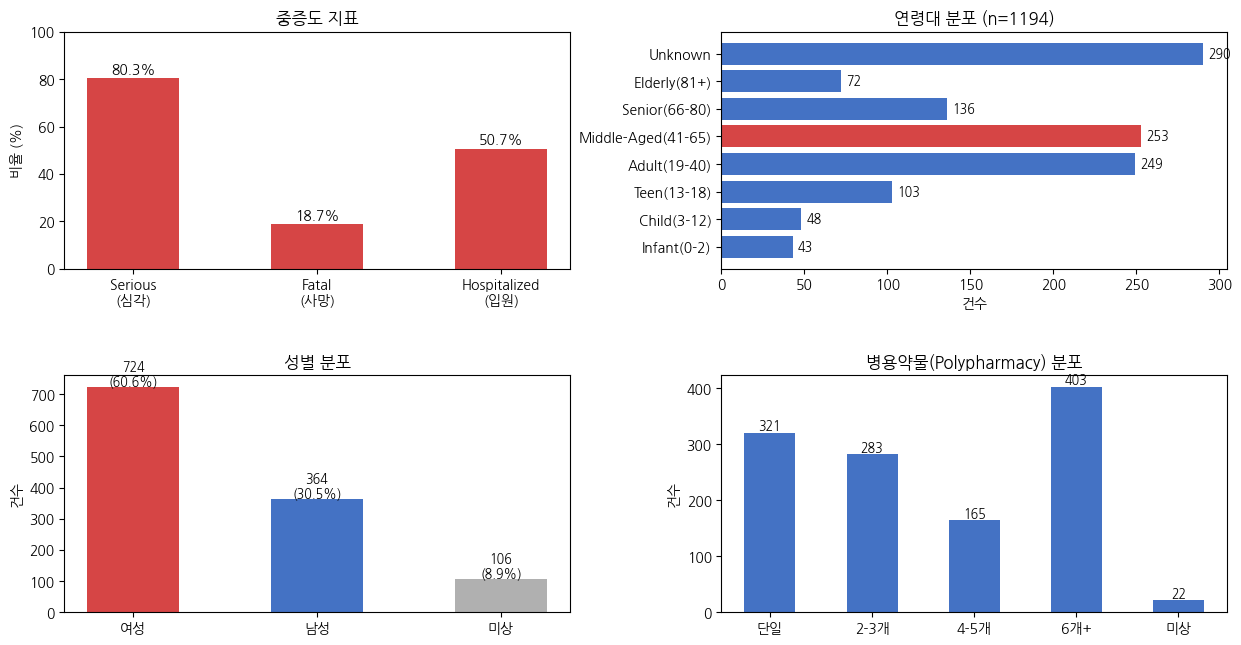

In [2]:
# ── 색상 컨벤션 ──
RED, BLUE, GRAY = '#D64545', '#4472C4', '#B0B0B0'

fig = plt.figure(figsize=(15, 12))
gs = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.3)

# 1. 중증도 지표
ax1 = fig.add_subplot(gs[0, 0])
metrics = ['Serious\n(심각)', 'Fatal\n(사망)', 'Hospitalized\n(입원)']
vals = [(single['serious']=='Yes').mean()*100,
        single['is_fatal'].mean()*100,
        single['is_hospitalized'].mean()*100]
bars = ax1.bar(metrics, vals, color=RED, width=0.5)
ax1.set_ylabel('비율 (%)'); ax1.set_title('중증도 지표', fontweight='bold'); ax1.set_ylim(0, 100)
for b, v in zip(bars, vals):
    ax1.text(b.get_x()+b.get_width()/2, v+2, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

# 2. 연령대 분포
ax2 = fig.add_subplot(gs[0, 1])
age_order = ['Infant(0-2)','Child(3-12)','Teen(13-18)','Adult(19-40)',
             'Middle-Aged(41-65)','Senior(66-80)','Elderly(81+)','Unknown']
age_counts = single['age_group'].value_counts().reindex(age_order).fillna(0)
known_age_counts = age_counts.drop('Unknown')
top_age_group = known_age_counts.idxmax()
colors = [RED if a == top_age_group else BLUE for a in age_order]
ax2.barh(age_order, age_counts.values, color=colors)
ax2.set_xlabel('건수'); ax2.set_title(f'연령대 분포 (n={n})', fontweight='bold')
for i, v in enumerate(age_counts.values):
    ax2.text(v + 3, i, f'{int(v)}', va='center', fontsize=9)

# 3. 성별 분포
ax3 = fig.add_subplot(gs[1, 0])
sex_counts = single['patient_sex'].value_counts().reindex(['Female','Male','Unknown']).fillna(0)
ax3.bar(['여성','남성','미상'], sex_counts.values, color=[RED, BLUE, GRAY], width=0.5)
ax3.set_ylabel('건수'); ax3.set_title('성별 분포', fontweight='bold')
for i, v in enumerate(sex_counts.values):
    ax3.text(i, v + 5, f'{int(v)}\n({v/n*100:.1f}%)', ha='center', fontsize=9)

# 4. 병용약물(Polypharmacy) 분포
ax4 = fig.add_subplot(gs[1, 1])
poly_order = ['Single','2-3 Drugs','4-5 Drugs','Polypharmacy(6+)','Unknown']
poly_counts = single['drug_count_category'].value_counts().reindex(poly_order).fillna(0)
ax4.bar(['단일','2-3개','4-5개','6개+','미상'], poly_counts.values, color=BLUE, width=0.5)
ax4.set_ylabel('건수'); ax4.set_title('병용약물(Polypharmacy) 분포', fontweight='bold')
for i, v in enumerate(poly_counts.values):
    ax4.text(i, v + 5, f'{int(v)}', ha='center', fontsize=9)


/tmp/ipykernel_4586/3549087221.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  serious_by_age = single.groupby('age_group').apply(lambda g: (g['serious']=='Yes').mean()).reindex(age_order).fillna(0) * 100


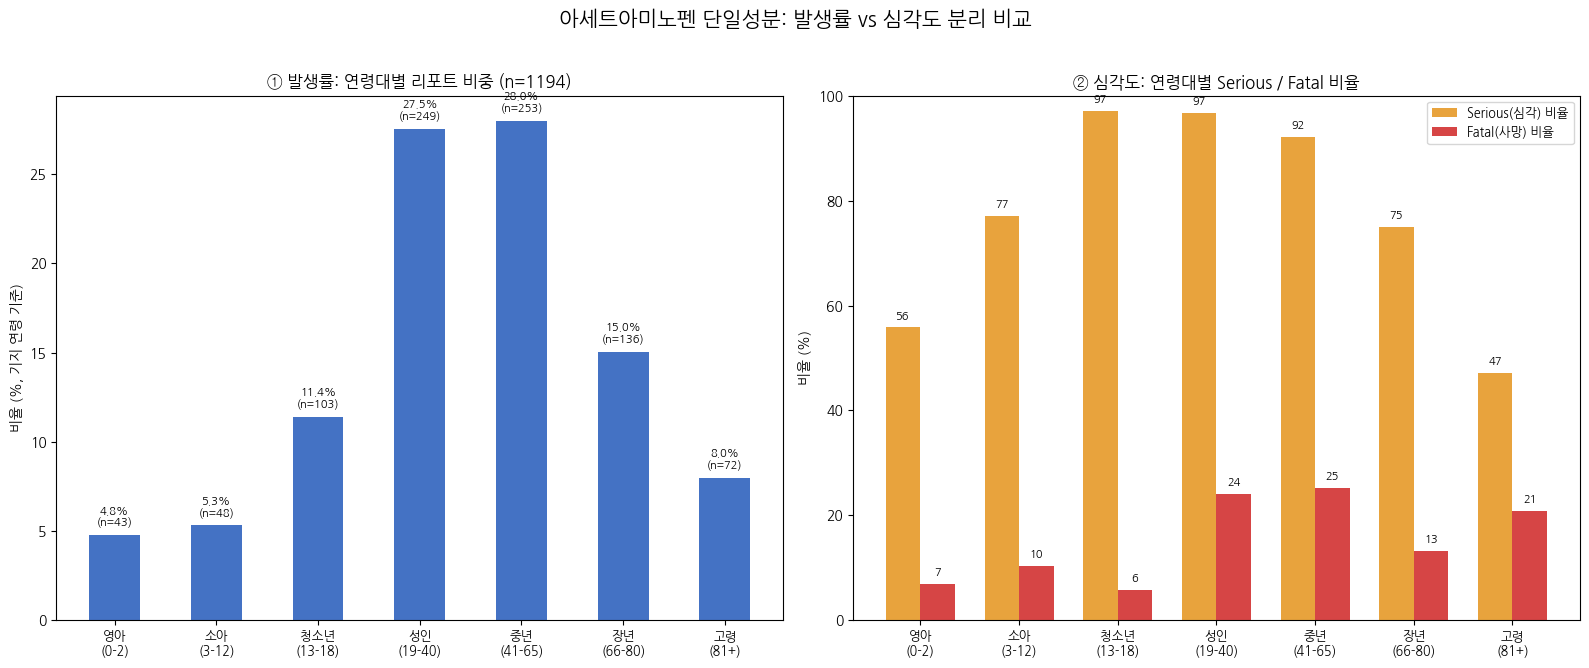

In [3]:
age_order = ['Infant(0-2)','Child(3-12)','Teen(13-18)','Adult(19-40)',
             'Middle-Aged(41-65)','Senior(66-80)','Elderly(81+)']
age_labels = ['영아\n(0-2)','소아\n(3-12)','청소년\n(13-18)','성인\n(19-40)',
              '중년\n(41-65)','장년\n(66-80)','고령\n(81+)']

# ── ① 발생률: 그룹 내 연령대별 리포트 비중 (기지 연령 기준) ──
age_counts = single['age_group'].value_counts().reindex(age_order).fillna(0)
age_pct = age_counts / age_counts.sum() * 100

# ── ② 심각도: 연령대별 Serious / Fatal 비율 ──
fatal_by_age = single.groupby('age_group')['is_fatal'].mean().reindex(age_order).fillna(0) * 100
serious_by_age = single.groupby('age_group').apply(lambda g: (g['serious']=='Yes').mean()).reindex(age_order).fillna(0) * 100
n_by_age = single.groupby('age_group').size().reindex(age_order).fillna(0).astype(int)

RED, BLUE, ORANGE = '#D64545', '#4472C4', '#E8A33D'

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# 왼쪽: 발생률 (그룹 내 연령 분포)
ax1 = axes[0]
x = np.arange(len(age_order))
ax1.bar(x, age_pct.values, color=BLUE, width=0.5)
ax1.set_xticks(x); ax1.set_xticklabels(age_labels, fontsize=9)
ax1.set_ylabel('비율 (%, 기지 연령 기준)')
ax1.set_title(f'① 발생률: 연령대별 리포트 비중 (n={n})', fontweight='bold')
for i, v in enumerate(age_pct.values):
    ax1.text(i, v + 0.5, f'{v:.1f}%\n(n={n_by_age.values[i]})', ha='center', fontsize=8)

# 오른쪽: 심각도 (연령대별 Serious / Fatal)
ax2 = axes[1]
w = 0.35
ax2.bar(x - w/2, serious_by_age.values, w, label='Serious(심각) 비율', color=ORANGE)
ax2.bar(x + w/2, fatal_by_age.values, w, label='Fatal(사망) 비율', color=RED)
ax2.set_xticks(x); ax2.set_xticklabels(age_labels, fontsize=9)
ax2.set_ylabel('비율 (%)')
ax2.set_title('② 심각도: 연령대별 Serious / Fatal 비율', fontweight='bold')
ax2.legend(fontsize=9); ax2.set_ylim(0, 100)
for i, v in enumerate(serious_by_age.values):
    ax2.text(i - w/2, v + 1.5, f'{v:.0f}', ha='center', fontsize=8)
for i, v in enumerate(fatal_by_age.values):
    ax2.text(i + w/2, v + 1.5, f'{v:.0f}', ha='center', fontsize=8)

fig.suptitle('아세트아미노펜 단일성분: 발생률 vs 심각도 분리 비교', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


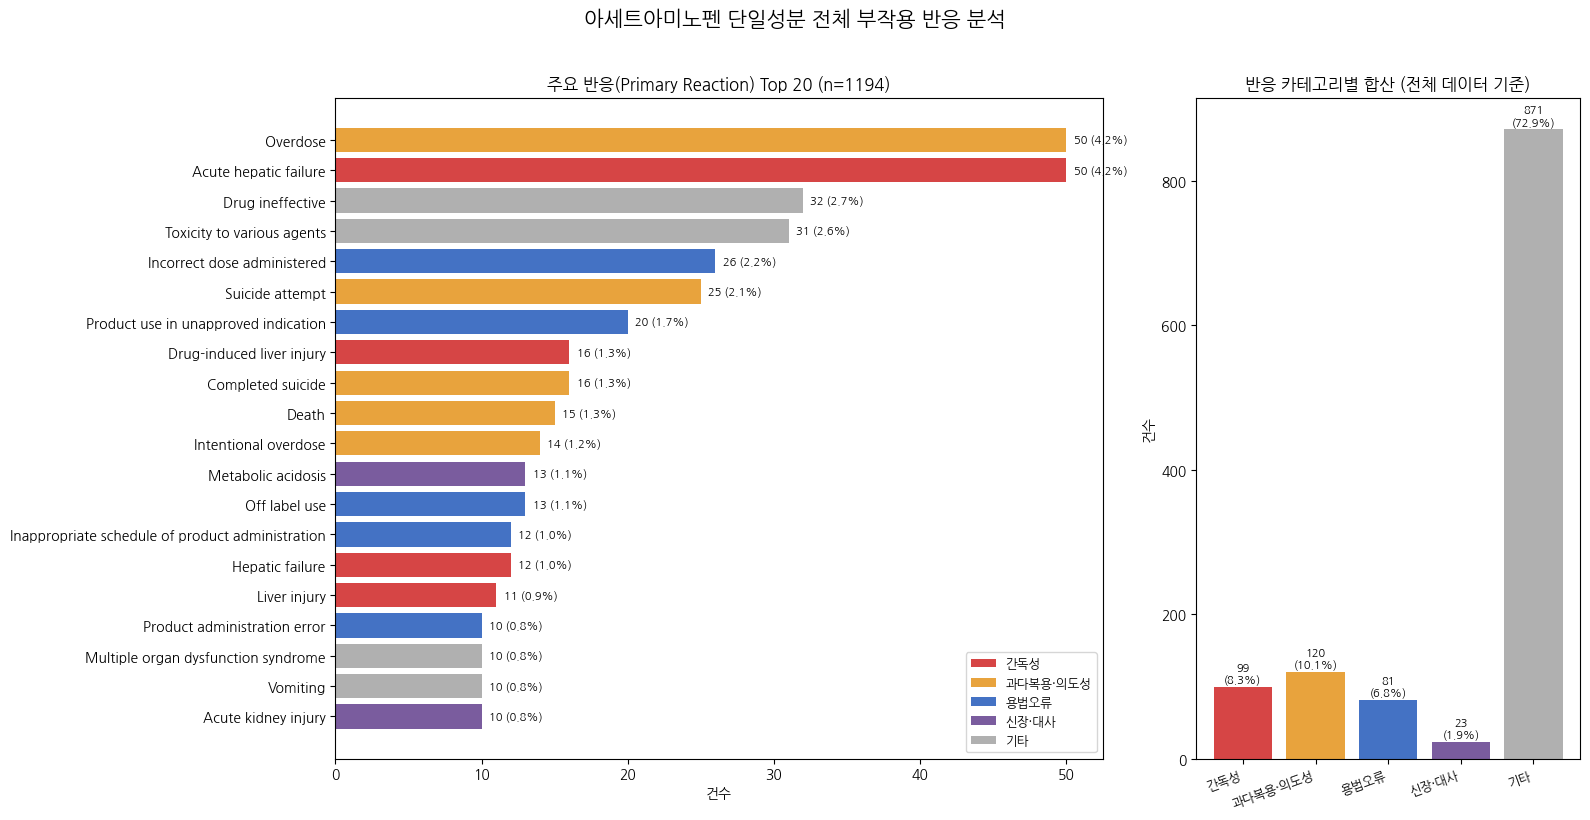

In [4]:
# ── 반응 카테고리 정의 ──
CATEGORY = {
    'Acute hepatic failure': '간독성', 'Drug-induced liver injury': '간독성',
    'Hepatic failure': '간독성', 'Liver injury': '간독성', 'Hepatitis': '간독성',
    'Overdose': '과다복용·의도성', 'Suicide attempt': '과다복용·의도성',
    'Completed suicide': '과다복용·의도성', 'Intentional overdose': '과다복용·의도성',
    'Death': '과다복용·의도성',
    'Incorrect dose administered': '용법오류', 'Product use in unapproved indication': '용법오류',
    'Off label use': '용법오류', 'Inappropriate schedule of product administration': '용법오류',
    'Product administration error': '용법오류',
    'Acute kidney injury': '신장·대사', 'Metabolic acidosis': '신장·대사',
}
COLORS = {
    '간독성': '#D64545', '과다복용·의도성': '#E8A33D',
    '용법오류': '#4472C4', '신장·대사': '#7A5C9E', '기타': '#B0B0B0',
}

top20 = single['primary_reaction'].value_counts().head(20).sort_values()
cats = [CATEGORY.get(r, '기타') for r in top20.index]
colors = [COLORS[c] for c in cats]

fig, axes = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={'width_ratios': [2, 1]})

# 왼쪽: Top20 반응
ax1 = axes[0]
ax1.barh(top20.index, top20.values, color=colors)
ax1.set_xlabel('건수')
ax1.set_title(f'주요 반응(Primary Reaction) Top 20 (n={n})', fontweight='bold')
for i, v in enumerate(top20.values):
    ax1.text(v + 0.5, i, f'{int(v)} ({v/n*100:.1f}%)', va='center', fontsize=8)
legend_elems = [Patch(facecolor=c, label=cat) for cat, c in COLORS.items()]
ax1.legend(handles=legend_elems, loc='lower right', fontsize=9)

# 오른쪽: 카테고리별 합산
single['카테고리'] = single['primary_reaction'].map(CATEGORY).fillna('기타')
cat_order = ['간독성', '과다복용·의도성', '용법오류', '신장·대사', '기타']
cat_counts = single['카테고리'].value_counts().reindex(cat_order).fillna(0)
ax2 = axes[1]
ax2.bar(cat_order, cat_counts.values, color=[COLORS[c] for c in cat_order])
ax2.set_ylabel('건수')
ax2.set_title('반응 카테고리별 합산 (전체 데이터 기준)', fontweight='bold')
ax2.set_xticks(range(len(cat_order)))
ax2.set_xticklabels(cat_order, rotation=20, ha='right', fontsize=9)
for i, v in enumerate(cat_counts.values):
    ax2.text(i, v + 5, f'{int(v)}\n({v/n*100:.1f}%)', ha='center', fontsize=8)

fig.suptitle('아세트아미노펜 단일성분 전체 부작용 반응 분석', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


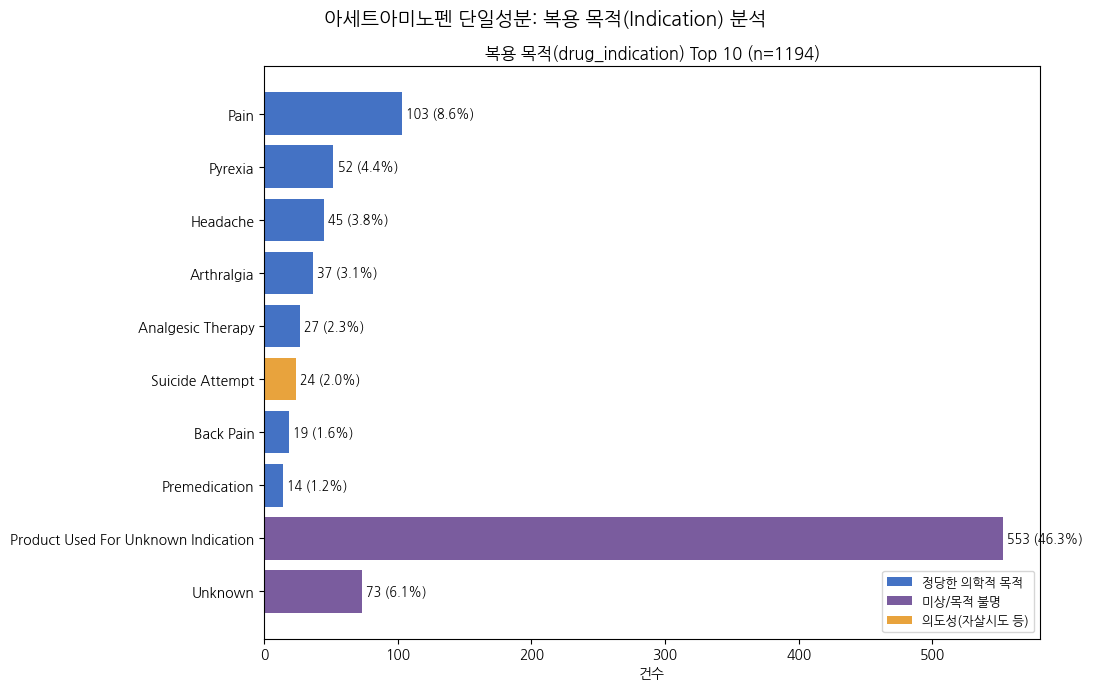

In [5]:
top10_ind = single['drug_indication'].value_counts().head(10)

UNKNOWN_LABELS = ['Product Used For Unknown Indication', 'Unknown']
CAT_MAP = {
    'Product Used For Unknown Indication': '미상', 'Unknown': '미상',
    'Suicide Attempt': '의도성', 'Suspected Suicide': '의도성',
}

# 미상 항목은 맨 아래로, 나머지는 건수순
known = top10_ind.drop(labels=[l for l in UNKNOWN_LABELS if l in top10_ind.index], errors='ignore').sort_values()
unknown = top10_ind[top10_ind.index.isin(UNKNOWN_LABELS)].sort_values()
ordered = pd.concat([unknown, known])  # barh는 아래부터 그려지므로 미상을 먼저 배치

colors = ['#7A5C9E' if CAT_MAP.get(i)=='미상' else ('#E8A33D' if CAT_MAP.get(i)=='의도성' else '#4472C4') for i in ordered.index]

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(ordered.index, ordered.values, color=colors)
ax.set_xlabel('건수')
ax.set_title(f'복용 목적(drug_indication) Top 10 (n={n})', fontweight='bold')
for i, (label, v) in enumerate(ordered.items()):
    ax.text(v + 3, i, f'{int(v)} ({v/n*100:.1f}%)', va='center', fontsize=9)

legend_elems = [Patch(facecolor='#4472C4', label='정당한 의학적 목적'),
                Patch(facecolor='#7A5C9E', label='미상/목적 불명'),
                Patch(facecolor='#E8A33D', label='의도성(자살시도 등)')]
ax.legend(handles=legend_elems, loc='lower right', fontsize=9)

fig.suptitle('아세트아미노펜 단일성분: 복용 목적(Indication) 분석', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


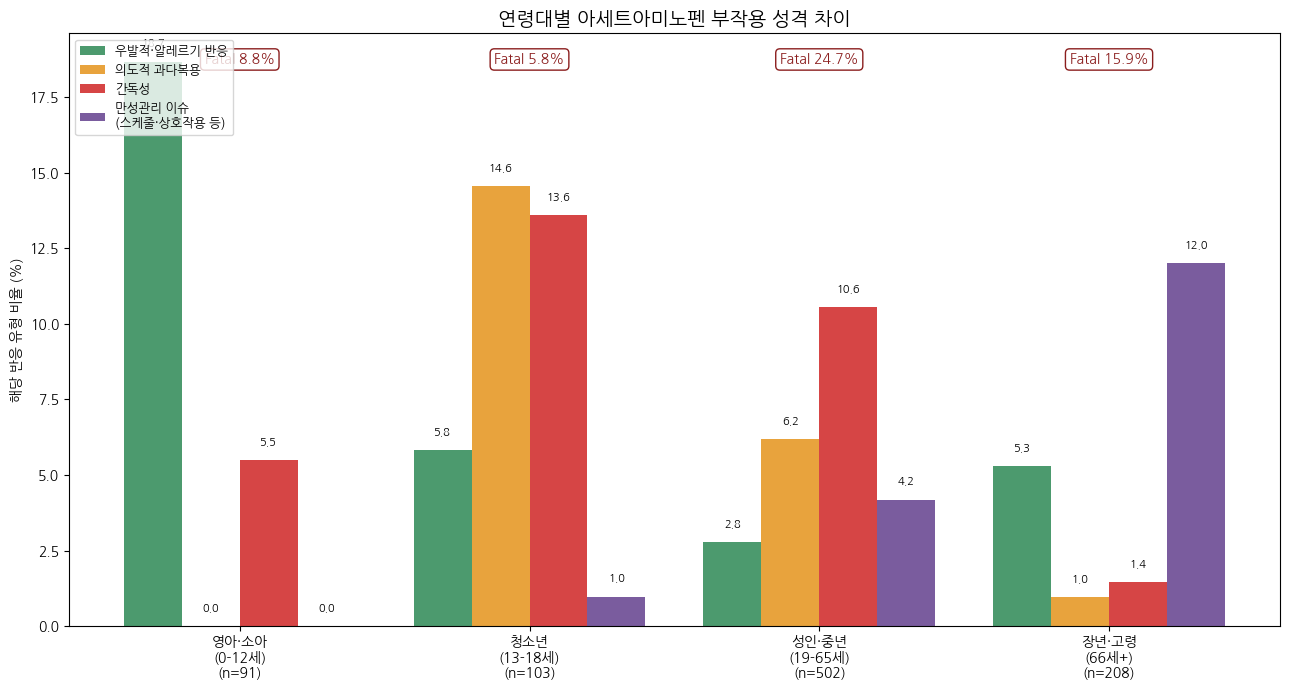

In [6]:
# ── 연령대를 4개 그룹으로 재분류 ──
age_band_map = {
    'Infant(0-2)':'영아·소아\n(0-12세)', 'Child(3-12)':'영아·소아\n(0-12세)',
    'Teen(13-18)':'청소년\n(13-18세)',
    'Adult(19-40)':'성인·중년\n(19-65세)', 'Middle-Aged(41-65)':'성인·중년\n(19-65세)',
    'Senior(66-80)':'장년·고령\n(66세+)', 'Elderly(81+)':'장년·고령\n(66세+)',
}
single['age_band'] = single['age_group'].map(age_band_map)
band_df = single.dropna(subset=['age_band'])

# ── 반응 카테고리 정의 ──
intentional = ['Suicide attempt','Completed suicide','Intentional overdose','Intentional drug misuse']
hepatic = ['Acute hepatic failure','Drug-induced liver injury','Hepatic failure','Liver injury','Hepatitis']
accidental_allergic = ['Vomiting','Urticaria','Toxic epidermal necrolysis','Incorrect dose administered',
                       'Product administration error','Rash','Pruritus','Nausea']
chronic_mgmt = ['Inappropriate schedule of product administration','Gastrointestinal haemorrhage',
                'Upper gastrointestinal haemorrhage','Lower gastrointestinal haemorrhage',
                'Drug interaction','Metabolic acidosis','Acute kidney injury','Haematuria']

band_order = ['영아·소아\n(0-12세)','청소년\n(13-18세)','성인·중년\n(19-65세)','장년·고령\n(66세+)']

metrics = {
    '우발적·알레르기 반응': accidental_allergic,
    '의도적 과다복용': intentional,
    '간독성': hepatic,
    '만성관리 이슈\n(스케줄·상호작용 등)': chronic_mgmt,
}
COLORS = {
    '우발적·알레르기 반응': '#4C9A6E', '의도적 과다복용': '#E8A33D',
    '간독성': '#D64545', '만성관리 이슈\n(스케줄·상호작용 등)': '#7A5C9E',
}

# ── 그룹별 비율 계산 ──
data = {label: [band_df[band_df['age_band']==b]['primary_reaction'].isin(r).mean()*100 for b in band_order]
        for label, r in metrics.items()}
fatal_by_band = [band_df[band_df['age_band']==b]['is_fatal'].mean()*100 for b in band_order]
n_by_band = [len(band_df[band_df['age_band']==b]) for b in band_order]

# ── 그래프 ──
x = np.arange(len(band_order))
w = 0.2

fig, ax = plt.subplots(figsize=(13, 7))
for i, (label, vals) in enumerate(data.items()):
    offset = (i - 1.5) * w
    bars = ax.bar(x + offset, vals, w, label=label, color=COLORS[label])
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.5, f'{v:.1f}', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([f"{b}\n(n={n})" for b, n in zip(band_order, n_by_band)], fontsize=10)
ax.set_ylabel('해당 반응 유형 비율 (%)')
ax.set_title('연령대별 아세트아미노펜 부작용 성격 차이', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)

for i, (fv, nv) in enumerate(zip(fatal_by_band, n_by_band)):
    ax.text(i, ax.get_ylim()[1]*0.95, f'Fatal {fv:.1f}%', ha='center', fontsize=10,
            fontweight='bold', color='#8B1E1E',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#8B1E1E'))

plt.tight_layout()
plt.show()


/tmp/ipykernel_4586/3822640452.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  serious_by_cat = single.groupby('카테고리').apply(lambda g: (g['serious']=='Yes').mean()).reindex(cat_order) * 100


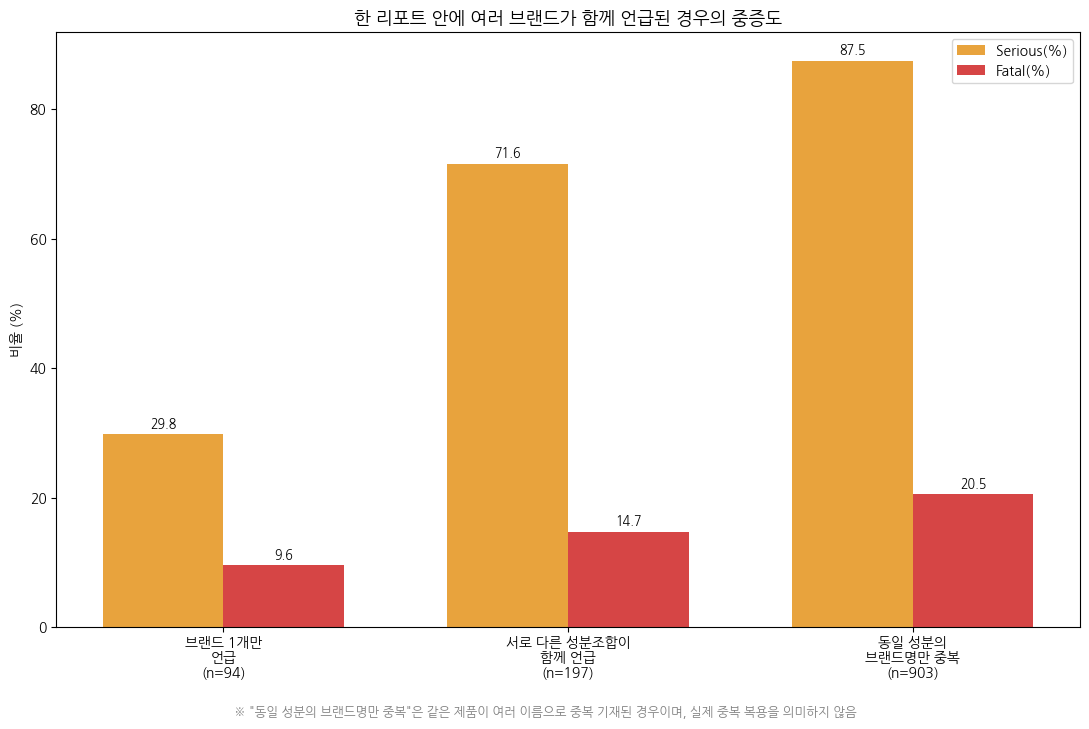

In [7]:
def analyze(text):
    if pd.isna(text):
        return None
    segs = [s.strip() for s in text.split(';') if s.strip()]
    comps = []
    for s in segs:
        comp = s.split(':', 1)[1].strip() if ':' in s else s.strip()
        comp = re.sub(r'\(.*?\)', '', comp).strip()
        comps.append(comp)
    return comps

single['comps'] = single['전체_활성성분'].apply(analyze)
single['num_brands'] = single['comps'].apply(lambda x: len(x) if x else 0)
single['num_unique_comps'] = single['comps'].apply(lambda x: len(set(x)) if x else 0)

def category(row):
    if row['num_brands'] <= 1:
        return '브랜드 1개만\n언급'
    elif row['num_unique_comps'] > 1:
        return '서로 다른 성분조합이\n함께 언급'
    else:
        return '동일 성분의\n브랜드명만 중복'

single['카테고리'] = single.apply(category, axis=1)
cat_order = ['브랜드 1개만\n언급', '서로 다른 성분조합이\n함께 언급', '동일 성분의\n브랜드명만 중복']

n_by_cat = single['카테고리'].value_counts().reindex(cat_order)
fatal_by_cat = single.groupby('카테고리')['is_fatal'].mean().reindex(cat_order) * 100
serious_by_cat = single.groupby('카테고리').apply(lambda g: (g['serious']=='Yes').mean()).reindex(cat_order) * 100

x = range(len(cat_order))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 7))
ax.bar([i - w/2 for i in x], serious_by_cat.values, w, label='Serious(%)', color='#E8A33D')
ax.bar([i + w/2 for i in x], fatal_by_cat.values, w, label='Fatal(%)', color='#D64545')
ax.set_xticks(list(x))
ax.set_xticklabels([f"{c}\n(n={n_by_cat[c]})" for c in cat_order], fontsize=10)
ax.set_ylabel('비율 (%)')
ax.set_title('한 리포트 안에 여러 브랜드가 함께 언급된 경우의 중증도', fontsize=13, fontweight='bold')
ax.legend()
for i, (s, fv) in enumerate(zip(serious_by_cat.values, fatal_by_cat.values)):
    ax.text(i - w/2, s + 1, f'{s:.1f}', ha='center', fontsize=9)
    ax.text(i + w/2, fv + 1, f'{fv:.1f}', ha='center', fontsize=9)

fig.text(0.5, -0.03,
          '※ "동일 성분의 브랜드명만 중복"은 같은 제품이 여러 이름으로 중복 기재된 경우이며, 실제 중복 복용을 의미하지 않음',
          ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()
